## 1. Reading, Displaying and Saving an Image

In [ ]:
from matplotlib import pyplot as plt
import cv2
import numpy as np

In [2]:
path = "C:/Users/YEO/OneDrive/Desktop/Degree/YEAR 3/Sem2/TCV/LAB/Images/hamster.jpg"

In [ ]:
img = cv2.imread(path)
plt.imshow(img), plt.axis('off')

(<matplotlib.image.AxesImage at 0x1d460135590>, (-0.5, 633.5, 356.5, -0.5))

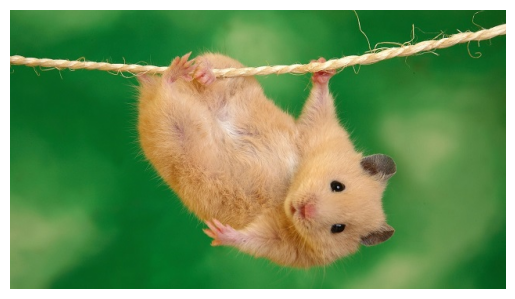

In [ ]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img), plt.axis('off')

In [ ]:
img.shape

(357, 634, 3)

In [ ]:
(h, w, c) = img.shape
print(img.shape)
print(img.size)
print(img.dtype)
print('width={}, height={}, channels={}'.format(w, h, c))

(357, 634, 3)
679014
uint8
width=634, height=357, channels=3


In [ ]:
cv2.namedWindow('Image', cv2.WINDOW_NORMAL)
cv2.imshow('Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imwrite('hamster_png.png', img)

True

## 2. Accessing and Modifying Pixel Values

In [ ]:
img = cv2.imread('Images/hamster.jpg')

px = img[200, 400]
print(px)

[135 192 237]


In [ ]:
img[200, 400] = [255, 255, 255]

px = img[200, 400]
print(px)

[255 255 255]


In [ ]:
# Reference ROI
px = img[200:250, 400:450]
print(px)

[[[255 255 255]
  [133 190 235]
  [134 192 234]
  ...
  [129 157 187]
  [115 138 164]
  [ 95 115 140]]

 [[138 195 240]
  [138 195 240]
  [137 194 239]
  ...
  [119 149 178]
  [123 147 175]
  [103 126 152]]

 [[135 194 240]
  [138 197 242]
  [139 196 241]
  ...
  [140 171 202]
  [121 149 179]
  [105 132 159]]

 ...

 [[132 169 213]
  [131 170 214]
  [132 171 215]
  ...
  [128 172 219]
  [131 173 220]
  [131 173 220]]

 [[138 175 219]
  [137 174 218]
  [134 174 216]
  ...
  [126 171 215]
  [130 172 217]
  [129 171 216]]

 [[136 173 217]
  [136 173 217]
  [134 174 216]
  ...
  [125 170 214]
  [128 170 215]
  [125 167 212]]]


In [ ]:
# Make a copy of the image
img1 = img.copy()

# Modify ROI
img1[200:250, 400:450] = [255, 255, 255]

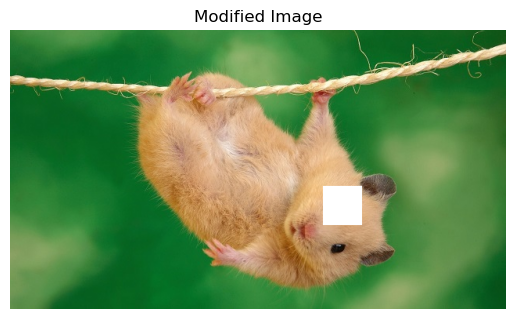

In [ ]:
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title('Modified Image')
plt.axis('off')
plt.show()

## 3. Array Sicing and Copping

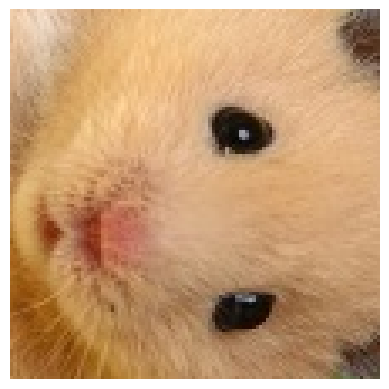

In [ ]:
img = cv2.imread('Images/hamster.jpg', 1)
img2 = img.copy()

face = img[190:300, 350:460] #ROI

# This is only for Colab
# cv2_imshow(face)

# Convert BGR -> RGB for correct colors in matplotlib
face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

# Display
plt.imshow(face_rgb)
plt.axis('off')  # Hide axes
plt.show()

## 4. Splitting and Merging Image Channels

<function matplotlib.pyplot.show(close=None, block=None)>

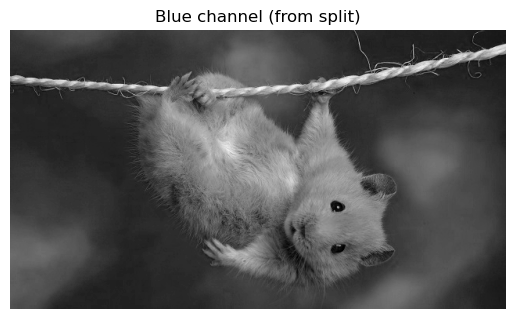

In [ ]:
img = cv2.imread('Images/hamster.jpg')

b, g, r = cv2.split(img)

# Display the blue channel
plt.imshow(b, cmap='gray')
plt.title('Blue channel (from split)')
plt.axis('off')
plt.show

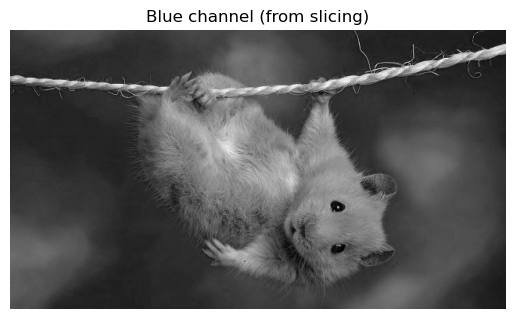

In [ ]:
# Alternatively using slicing
b_alt = img[:,:,0] # Blue channel
plt.imshow(b_alt, cmap='gray')
plt.title('Blue channel (from slicing)')
plt.axis('off')
plt.show()

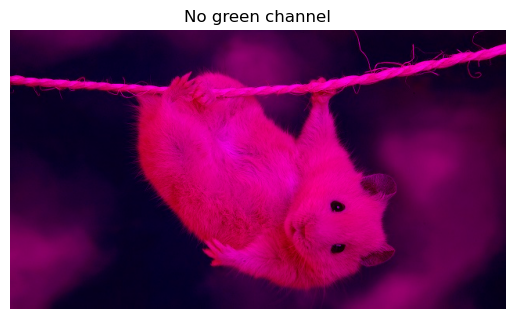

In [ ]:
# No green channel (Zero Out Green)
img_no_green = img.copy()
img_no_green[:,:,1] = 0

plt.imshow(cv2.cvtColor(img_no_green, cv2.COLOR_BGR2RGB))
plt.title('No green channel')
plt.axis('off')
plt.show()

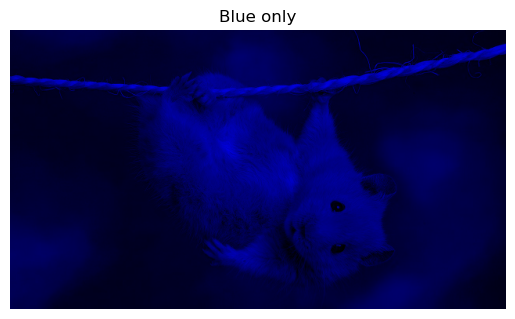

In [ ]:
# Show blue only
img_blue_only = img.copy()
img_blue_only[:,:,1] = 0 # Remove green
img_blue_only[:,:,2] = 0 # Remove red

plt.imshow(cv2.cvtColor(img_blue_only, cv2.COLOR_BGR2RGB))
plt.title('Blue only')
plt.axis('off')
plt.show()

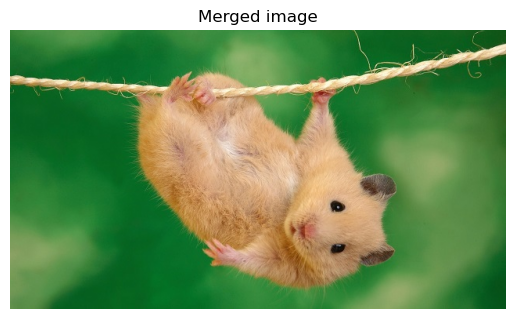

In [ ]:
# Merge back to form full BGR image again
img_merged = cv2.merge((b, g, r))
plt.imshow(cv2.cvtColor(img_merged, cv2.COLOR_BGR2RGB))
plt.title('Merged image')
plt.axis('off')
plt.show()

## Other image operations

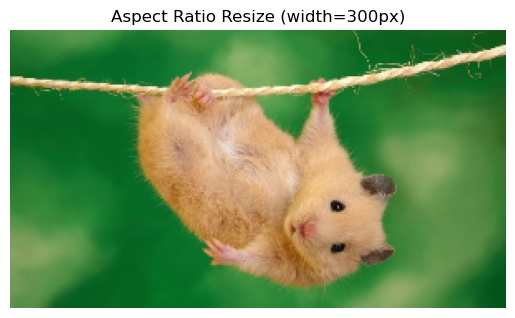

In [ ]:
# Resize the width to 300px based on the aspect ratio
(h, w, c) = img.shape
r = 300.0 / w
dim = (300, int(h * r))
resized = cv2.resize(img, dim)

# Convert BGR to RGB before showing
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

plt.imshow(resized_rgb)
plt.title('Aspect Ratio Resize (width=300px)')
plt.axis('off')
plt.show()

(149, 841)


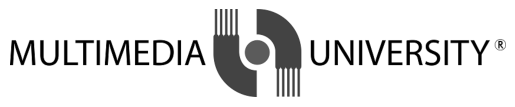

In [ ]:
img = cv2.imread('Images/logo.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap="gray")
plt.axis('off')

(height, width) = img.shape
print(img.shape)

True

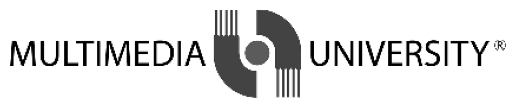

In [ ]:
reduction_step = 2
rows_keep = range(0, height, reduction_step) 
cols_keep = range(0, width, reduction_step)

img_subsample = np.zeros((len(rows_keep), len(cols_keep)), dtype=np.uint8)
for i, row_value in enumerate(rows_keep):
    for j, col_value in enumerate(cols_keep):
        img_subsample[i, j] = img[row_value, col_value]
        
plt.imshow(img_subsample, cmap="gray")
plt.axis('off')

cv2.imwrite('subsampled.jpg', img_subsample)

In [ ]:
img = cv2.imread('subsampled.jpg')
img_blur = cv2.blur(img, (2, 2))

plt.subplot(1, 2, 1), plt.imshow(img), plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(img_blur), plt.title('Blurred')
plt.xticks([]), plt.yticks([])

plt.show()                                         

NameError: name 'cv2' is not defined

In [ ]:
# Rotate an image 45 degrees clockwise.
# First, compute the image center
img = cv2. imread('/content/drive/MyDrive/hamster.jpg', 1)
img = cv2.cvtcolor(img, cv2.COLOR_BGR2RGB)
center = (w // 2, h // 2) # Use // to perform integer math (i.e., no floating point values)
# Construct the rotation matrix
M = cv2. getRotationMatrix2D(center, -45, 1.0)
# Apply the affine warp
rotated = cv2.warpAffine(img, M, (w, h))
plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis(' off')
olt.show()